## Satisfaction EDA (Professional Version)
Goal: Measure how customer satisfaction signals relate to churn using visual evidence, statistical testing, and effect size.

### Scope
- Returns_Rate
- Customer_Service_Calls

### Workflow
1. Standardized 3-view chart per feature
2. Mann-Whitney U + rank-biserial effect size
3. Quartile churn trend and executive summary

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

sns.set_theme(style='whitegrid')

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

In [3]:
satisfaction_feature_names = [
    'Returns_Rate',
    'Customer_Service_Calls',
]

satisfaction_data = df[satisfaction_feature_names].copy()

In [4]:
summary_stats = satisfaction_data.describe().T
summary_stats['skewness'] = satisfaction_data.skew()
summary_stats['kurtosis'] = satisfaction_data.kurt()
summary_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Returns_Rate,50000.0,6.565861,5.872081,0.0,3.1,5.4,8.6,99.615734,6.185957,79.41406
Customer_Service_Calls,50000.0,5.679540,2.671844,0.0,4.0,5.0,7.0,21.000000,0.444784,0.14186


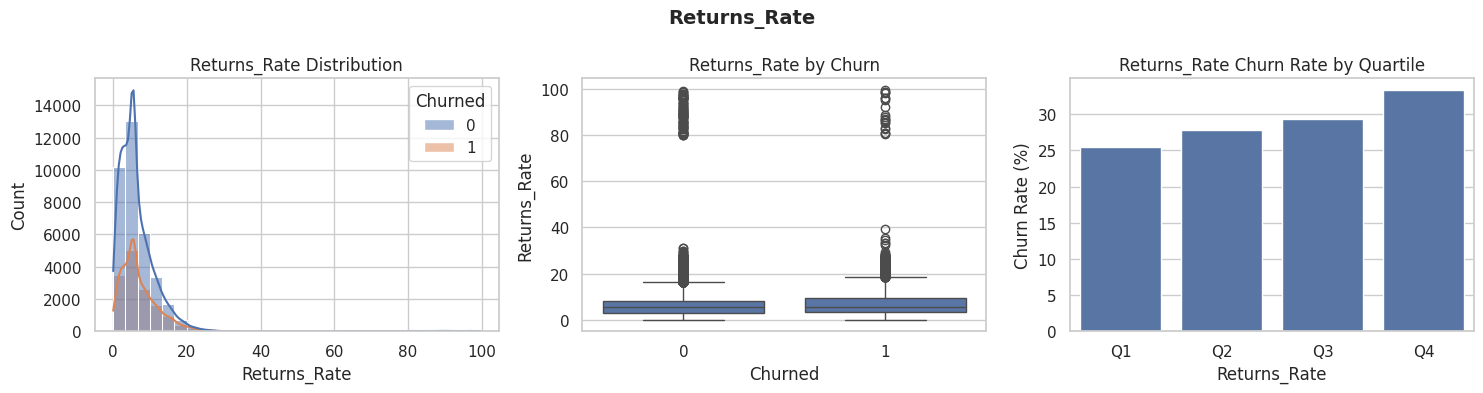

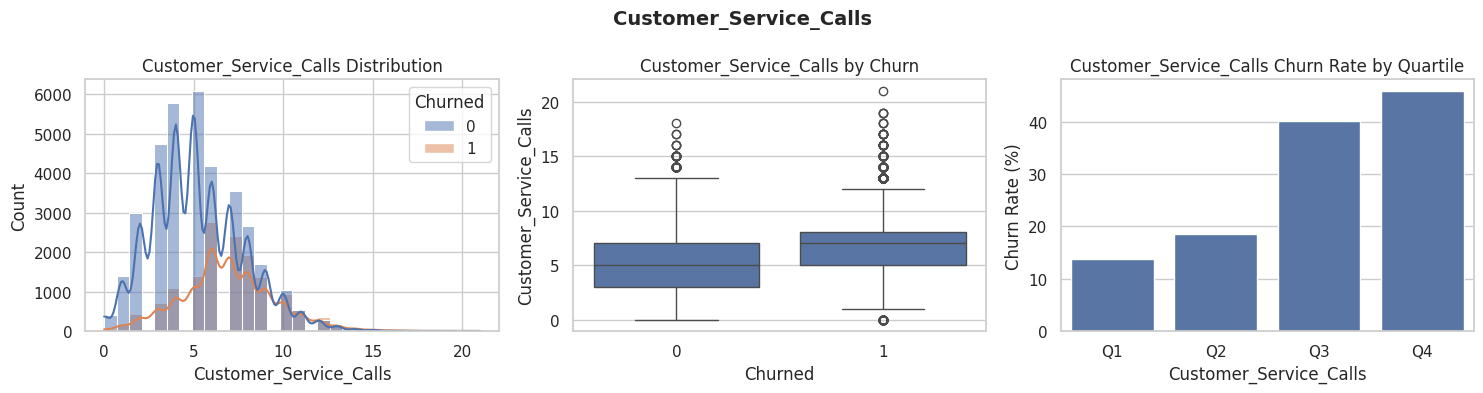

In [5]:
def analyze_feature(feature, df):
    """Analyze one satisfaction feature in 3 views: distribution, churn gap, and churn trend."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    sns.histplot(data=df, x=feature, hue='Churned', bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'{feature} Distribution')
    
    sns.boxplot(data=df, x='Churned', y=feature, ax=axes[1])
    axes[1].set_title(f'{feature} by Churn')
    
    bins = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    churn_rate = df.groupby(bins, observed=True)['Churned'].mean() * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[2])
    axes[2].set_title(f'{feature} Churn Rate by Quartile')
    axes[2].set_ylabel('Churn Rate (%)')
    
    plt.suptitle(feature, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

for feature in satisfaction_feature_names:
    analyze_feature(feature, df)

In [6]:
def rank_biserial_from_u(u_stat, n_churn, n_non_churn):
    auc_probability = u_stat / (n_churn * n_non_churn)
    return 2 * auc_probability - 1

def effect_label(value):
    abs_value = abs(value)
    if abs_value >= 0.5:
        return 'Large'
    if abs_value >= 0.3:
        return 'Medium'
    if abs_value >= 0.1:
        return 'Small'
    return 'Negligible'

rows = []

for feature in satisfaction_feature_names:
    churn = df.loc[df['Churned'] == 1, feature].dropna()
    non_churn = df.loc[df['Churned'] == 0, feature].dropna()

    u_stat, p_value = stats.mannwhitneyu(churn, non_churn, alternative='two-sided')
    rb = rank_biserial_from_u(u_stat, len(churn), len(non_churn))

    bins = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    quartile_df = pd.DataFrame({'quartile': bins, 'Churned': df['Churned']})
    quartile_rate = quartile_df.groupby('quartile', observed=True)['Churned'].mean() * 100

    rows.append({
        'feature': feature,
        'corr_with_churn': df[feature].corr(df['Churned']),
        'u_stat': u_stat,
        'p_value': p_value,
        'rank_biserial': rb,
        'effect_size_label': effect_label(rb),
        'churn_q1_pct': quartile_rate.iloc[0],
        'churn_q4_pct': quartile_rate.iloc[-1],
        'q4_minus_q1_pct': quartile_rate.iloc[-1] - quartile_rate.iloc[0],
    })

satisfaction_summary = pd.DataFrame(rows).sort_values('q4_minus_q1_pct', ascending=False).reset_index(drop=True)
satisfaction_summary

,feature,corr_with_churn,u_stat,p_value,rank_biserial,effect_size_label,churn_q1_pct,churn_q4_pct,q4_minus_q1_pct
0,Customer_Service_Calls,0.290384,353950073.0,0.000000e+00,0.378049,Medium,13.785336,45.798707,32.013371
1,Returns_Rate,0.051122,278968534.0,1.083147e-51,0.086120,Negligible,25.453546,33.285152,7.831606


In [7]:
display_cols = [
    'feature', 'corr_with_churn', 'p_value', 'rank_biserial',
    'effect_size_label', 'churn_q1_pct', 'churn_q4_pct', 'q4_minus_q1_pct'
]

display_df = satisfaction_summary.copy()
display_df['corr_with_churn'] = display_df['corr_with_churn'].round(3)
display_df['p_value'] = display_df['p_value'].map(lambda x: f'{x:.3e}')
display_df['rank_biserial'] = display_df['rank_biserial'].round(3)
display_df['churn_q1_pct'] = display_df['churn_q1_pct'].round(2)
display_df['churn_q4_pct'] = display_df['churn_q4_pct'].round(2)
display_df['q4_minus_q1_pct'] = display_df['q4_minus_q1_pct'].round(2)
display_df[display_cols]

,feature,corr_with_churn,p_value,rank_biserial,effect_size_label,churn_q1_pct,churn_q4_pct,q4_minus_q1_pct
0,Customer_Service_Calls,0.290,0.000e+00,0.378,Medium,13.79,45.80,32.01
1,Returns_Rate,0.051,1.083e-51,0.086,Negligible,25.45,33.29,7.83


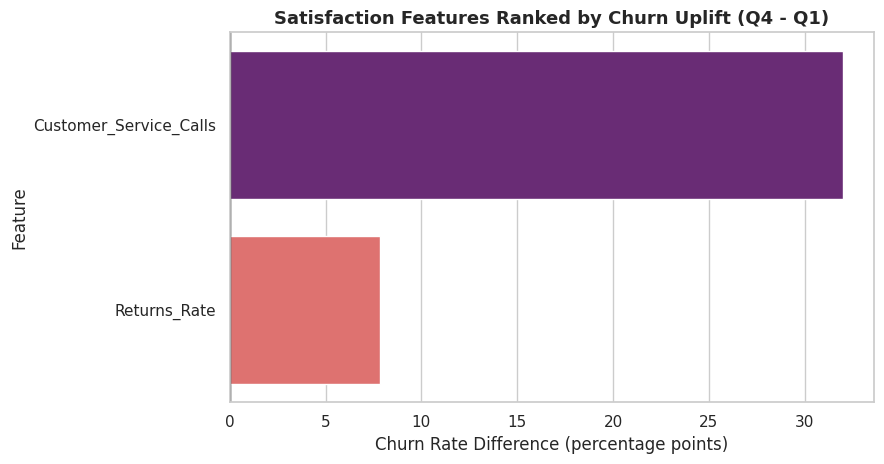

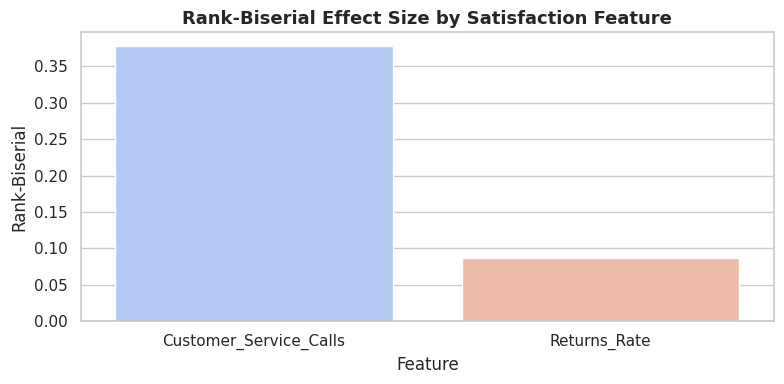

In [8]:
plot_df = satisfaction_summary.copy()

plt.figure(figsize=(9, 4.8))
sns.barplot(
    data=plot_df,
    x='q4_minus_q1_pct',
    y='feature',
    hue='feature',
    palette='magma',
    legend=False
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Satisfaction Features Ranked by Churn Uplift (Q4 - Q1)', fontsize=13, weight='bold')
plt.xlabel('Churn Rate Difference (percentage points)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
effect_df = plot_df.sort_values('rank_biserial', ascending=False)
sns.barplot(
    data=effect_df,
    x='feature',
    y='rank_biserial',
    hue='feature',
    palette='coolwarm',
    legend=False
)
plt.axhline(0, color='black', linewidth=1)
plt.title('Rank-Biserial Effect Size by Satisfaction Feature', fontsize=13, weight='bold')
plt.xlabel('Feature')
plt.ylabel('Rank-Biserial')
plt.tight_layout()
plt.show()

In [9]:
print('Executive Insight: Satisfaction vs Churn')
print('-----------------------------------------')
for _, row in satisfaction_summary.iterrows():
    direction = 'higher' if row['q4_minus_q1_pct'] > 0 else 'lower'
    print(
        f"- {row['feature']}: Q4 churn is {abs(row['q4_minus_q1_pct']):.2f}pp {direction} than Q1, "
        f"effect={row['effect_size_label']} (rb={row['rank_biserial']:.3f}), p={row['p_value']:.2e}"
    )

satisfaction_summary.to_csv('../../../Data/processed/satisfaction_professional_summary.csv', index=False)
print('Saved: Data/processed/satisfaction_professional_summary.csv')

Executive Insight: Satisfaction vs Churn
-----------------------------------------
- Customer_Service_Calls: Q4 churn is 32.01pp higher than Q1, effect=Medium (rb=0.378), p=0.00e+00
- Returns_Rate: Q4 churn is 7.83pp higher than Q1, effect=Negligible (rb=0.086), p=1.08e-51
Saved: Data/processed/satisfaction_professional_summary.csv
